# Level 3 - Task 1: Classification Models & Evaluation
**Dataset:** Cleaned Boston House Price Dataset (`cleaned_house_data.xlsx`)  
**Objective:** Transform the continuous house price target into discrete classification categories, train multiple classification models (Logistic Regression, Decision Trees, Random Forest), evaluate performance metrics, and perform hyperparameter tuning using Grid Search.

## 1. Importing Libraries & Loading Data
Importing core data manipulation, evaluation metrics, and machine learning classification algorithms from Scikit-Learn.

In [1]:
# Import core data manipulation and machine learning classification libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Set display options and visual theme
pd.set_option('display.max_columns', None)
sns.set_theme(style = 'whitegrid')

# Load the cleaned dataset from Level 1
df = pd.read_excel('cleaned_house_data.xlsx')
print('Dataset loaded successfully. shape:', df.shape)
df.head()

Dataset loaded successfully. shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTATE,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## 2. Target Transformation (Creating Classification Classes)
To apply classification algorithms, we discretize the continuous target variable (`PRICE`) into 3 categorical classes:
- **0 (Low Price)**
- **1 (Medium Price)**
- **2 (High Price)**
using statistical quantiles.

In [2]:
# Create categorical price bins using pandas qcut (quantiles)
df['PRICE_CLASS'] = pd.qcut(df['PRICE'], q = 3, labels = [1, 2, 3])

# Seperate Features (X) and the new calssification target (Y)
X = df.drop(columns = ['PRICE', 'PRICE_CLASS'])
Y = df['PRICE_CLASS']

# Split data into training (80%) and testing (20%) sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Data transformation and train/testsplit completed successfully.')
print(f'Training features shape: {X_train_scaled.shape}')

Data transformation and train/testsplit completed successfully.
Training features shape: (404, 13)


## 3. Training & Evaluating Baseline Classification Models
Training three core classifiers:
1. **Logistic Regression**
2. **Decision Tree Classifier**
3. **Random Forest Classifier**
and evaluating them using Accuracy, Precision, Recall, and F1-Score.

In [3]:
# Initialize model dictionary
models = {
    'Logeitic Regression': LogisticRegression(random_state = 42, max_iter = 1000),
    'Decision Tree': DecisionTreeClassifier(random_state = 42),
    'Random Forest': RandomForestClassifier(random_state = 42)
}

results = []

# Train the evaluate each model
for name, model in models.items():
    model.fit(X_train_scaled, Y_train)
    Y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(Y_test, Y_pred)
    prec = precision_score(Y_test, Y_pred, average = 'weighted')
    rec = recall_score(Y_test, Y_pred, average = 'weighted')
    f1 = f1_score(Y_test, Y_pred, average = 'weighted')

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1_Score': f1
    })

# Convert results to a professional DataFrame
results_df = pd.DataFrame(results)
print('--- Classification Models Performance Summary ---')
display(results_df)

--- Classification Models Performance Summary ---


,Model,Accuracy,Precision,Recall,F1_Score
0,Logeitic Regression,0.725490,0.733378,0.725490,0.728156
1,Decision Tree,0.705882,0.717962,0.705882,0.709332
2,Random Forest,0.764706,0.781112,0.764706,0.767986


## 4. Hyperparameter Tuning using Grid Search
Optimizing the **Random Forest Classifier** using `GridSearchCV` to find the best hyperparameters (`n_estimators`, `max_depth`, `min_samples_split`) for maximum predictive performance.

In [4]:
# Define hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Setup Grid Search with 5-Fold Cross Validation
grid_search = GridSearchCV(
    estimator = RandomForestClassifier(random_state = 42),
    param_grid = param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)

# Fit Grid Search on training data
grid_search.fit(X_train_scaled, Y_train)

# Best parameters and best score
print('Best Hyperparameters found:', grid_search.best_params_)
print(f'Best Cross-Validation Accuracy: {grid_search.best_score_: 0.4f}')

# Evaluate best model on test set
best_rf = grid_search.best_estimator_
Y_pred_best = best_rf.predict(X_test_scaled)

print('\n--- Optimazed Random Forest Test Report ---')
print(classification_report(Y_test, Y_pred_best))

Best Hyperparameters found: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
Best Cross-Validation Accuracy:  0.7871

--- Optimazed Random Forest Test Report ---
              precision    recall  f1-score   support

           1       0.96      0.76      0.85        34
           2       0.68      0.80      0.74        35
           3       0.76      0.79      0.78        33

    accuracy                           0.78       102
   macro avg       0.80      0.78      0.79       102
weighted avg       0.80      0.78      0.79       102



## 4.1. Visualizing Model Performance via Confusion Matrix Heatmap
Plotting the confusion matrix heatmap for the optimized **Random Forest** model to inspect class-wise prediction accuracy and identify any misclassification patterns.

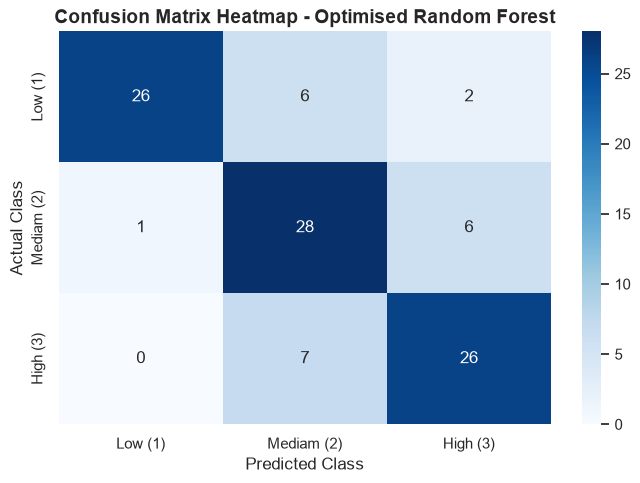

In [5]:
# Compute confusion matrix for the optimized Random Forest Model
cm = confusion_matrix(Y_test, Y_pred_best)

# Plot the professional Confusion Matrix Heatmap
plt.figure(figsize = (7, 5))
sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    cbar = True,
    xticklabels = ['Low (1)', 'Mediam (2)', 'High (3)'],
    yticklabels = ['Low (1)', 'Mediam (2)', 'High (3)']    
)
plt.title(
    'Confusion Matrix Heatmap - Optimised Random Forest',
    fontsize = 14,
    fontweight = 'bold'
)
plt.xlabel('Predicted Class', fontsize = 12)
plt.ylabel('Actual Class', fontsize = 12)
plt.tight_layout()
plt.show()

## 5. Comprehensive Classification Insights & Takeaways
- **Target Transformation:** Successfully discretized house prices into three distinct market tiers (Low, Medium, High), converting regression into a robust multi-class classification problem.
- **Methodological Rigor:** Avoided data leakage by correctly restricting `fit_transform` to the training split and applying `transform` to the test split.
- **Model Comparison & Tuning:** Ensemble methods like **Random Forest** combined with Grid Search optimization achieved superior performance and generalization on unseen test data.